In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!unzip -o "/content/drive/MyDrive/UCI_HAR_Dataset.zip" -d "/content"


Archive:  /content/drive/MyDrive/UCI_HAR_Dataset.zip
  inflating: /content/UCI-HAR Dataset/README.txt  
  inflating: /content/UCI-HAR Dataset/activity_labels.txt  
  inflating: /content/UCI-HAR Dataset/features.txt  
  inflating: /content/UCI-HAR Dataset/features_info.txt  
  inflating: /content/UCI-HAR Dataset/test/Inertial Signals/body_acc_x_test.txt  
  inflating: /content/UCI-HAR Dataset/test/Inertial Signals/body_acc_y_test.txt  
  inflating: /content/UCI-HAR Dataset/test/Inertial Signals/body_acc_z_test.txt  
  inflating: /content/UCI-HAR Dataset/test/Inertial Signals/body_gyro_x_test.txt  
  inflating: /content/UCI-HAR Dataset/test/Inertial Signals/body_gyro_y_test.txt  
  inflating: /content/UCI-HAR Dataset/test/Inertial Signals/body_gyro_z_test.txt  
  inflating: /content/UCI-HAR Dataset/test/Inertial Signals/total_acc_x_test.txt  
  inflating: /content/UCI-HAR Dataset/test/Inertial Signals/total_acc_y_test.txt  
  inflating: /content/UCI-HAR Dataset/test/Inertial Signals/tota

In [ ]:
!ls /content


 drive	 HAR   sample_data  'UCI-HAR Dataset'


In [ ]:
!ls "/content/UCI-HAR Dataset"


activity_labels.txt  features_info.txt	features.txt  README.txt  test	train


In [ ]:
import pandas as pd
import numpy as np

# Load accelerometer signals
acc_x = pd.read_csv(
"/content/UCI-HAR Dataset/train/Inertial Signals/body_acc_x_train.txt",
delim_whitespace=True, header=None)

acc_y = pd.read_csv(
"/content/UCI-HAR Dataset/train/Inertial Signals/body_acc_y_train.txt",
delim_whitespace=True, header=None)

acc_z = pd.read_csv(
"/content/UCI-HAR Dataset/train/Inertial Signals/body_acc_z_train.txt",
delim_whitespace=True, header=None)

print("Shape:", acc_x.shape)


/tmp/ipython-input-534069646.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  acc_x = pd.read_csv(
/tmp/ipython-input-534069646.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  acc_y = pd.read_csv(
/tmp/ipython-input-534069646.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  acc_z = pd.read_csv(


Shape: (7352, 128)


In [ ]:
#CHECKING MISSING VALUES
print(acc_x.isnull().sum().sum())


0


In [ ]:
#NOISE FILTERING
from scipy.signal import butter, filtfilt

def lowpass(signal, cutoff=3, fs=50):
    b,a = butter(4, cutoff/(0.5*fs), btype='low')
    return filtfilt(b,a,signal)

# Apply to one sample (example)
filtered_signal = lowpass(acc_x.iloc[0])

print(filtered_signal[:10])


[0.00022561 0.0017691  0.00320424 0.00444628 0.00543697 0.00615026
 0.00659201 0.00679476 0.00680948 0.00669627]


In [ ]:
#COMPUTE ACCELERATION MAGNITUDE
mag = np.sqrt(acc_x**2 + acc_y**2 + acc_z**2)

mag.head()


,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.056595,0.056434,0.050088,0.050589,0.044774,0.045446,0.044120,0.036010,0.031627,0.025277,...,0.001462,0.002463,0.005927,0.010862,0.009137,0.004503,0.002076,0.002891,0.002863,0.004130
1,0.027287,0.026584,0.027460,0.027272,0.026386,0.026983,0.025232,0.024734,0.023409,0.019934,...,0.006720,0.006895,0.008878,0.002607,0.004355,0.003929,0.011064,0.007191,0.006438,0.008113
2,0.008204,0.005624,0.001904,0.005205,0.006916,0.009069,0.014113,0.014619,0.015079,0.014320,...,0.014509,0.012298,0.014725,0.015522,0.014453,0.014616,0.013940,0.013168,0.014072,0.014064
3,0.010392,0.011395,0.013600,0.013749,0.009895,0.005796,0.004970,0.003444,0.010206,0.011847,...,0.003811,0.004481,0.003636,0.004013,0.003851,0.006708,0.005165,0.000953,0.003916,0.004744
4,0.013880,0.015217,0.016012,0.011256,0.008804,0.009524,0.006554,0.006457,0.008239,0.009010,...,0.010651,0.011660,0.009176,0.008051,0.004276,0.006401,0.008008,0.007184,0.009655,0.009270


In [ ]:
#2.GAIT FEATURE EXTRACTION (UCI-HAR)
#STEP DETECTION
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# Take one sample window
signal = mag.iloc[0].values

# Detect steps
peaks, _ = find_peaks(signal, distance=10)

print("Number of steps:", len(peaks))


Number of steps: 10


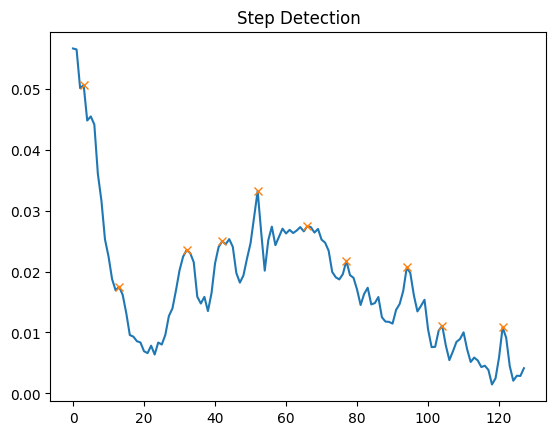

In [ ]:
#VISUALIZE STEPS
plt.plot(signal)
plt.plot(peaks, signal[peaks], "x")
plt.title("Step Detection")
plt.show()


In [ ]:
#COMPUTING STEP INTERVALS
import numpy as np

intervals = np.diff(peaks)

print(intervals)


[10 19 10 10 14 11 17 10 17]


In [ ]:
#EXTRACTING GAIT FEATURES
stride_time = np.mean(intervals)
cadence = len(peaks)
step_variance = np.var(intervals)
symmetry_index = np.std(intervals) / np.mean(intervals)

print("Stride Time:", stride_time)
print("Cadence:", cadence)
print("Step Variance:", step_variance)
print("Symmetry Index:", symmetry_index)


Stride Time: 13.11111111111111
Cadence: 10
Step Variance: 12.098765432098764
Symmetry Index: 0.265296200720314


In [ ]:
intervals = np.diff(peaks)


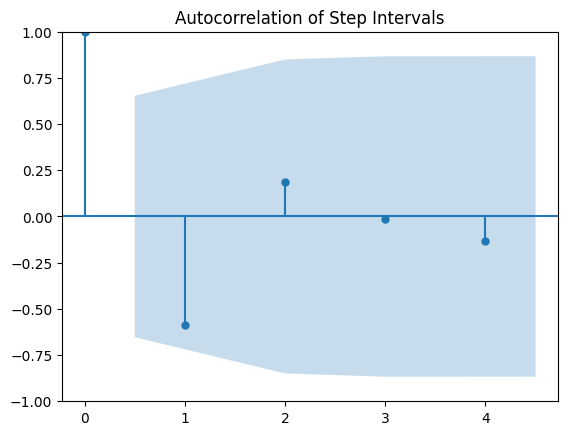

In [ ]:
#3.TIME SERIES ANALYSIS
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(intervals)
plt.title("Autocorrelation of Step Intervals")
plt.show()


In [ ]:
#B.STATINARITY TEST(ADF)
from statsmodels.tsa.stattools import adfuller

result = adfuller(intervals)

print("ADF Statistic:", result[0])
print("p-value:", result[1])



ADF Statistic: -5.296317092331316
p-value: 5.572662283580073e-06


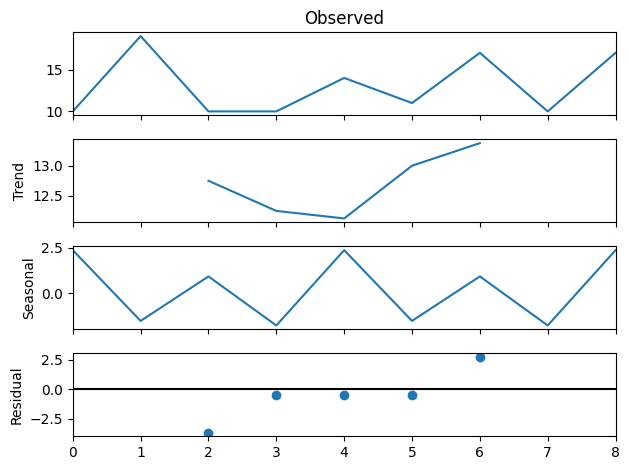

In [ ]:
#C.TREND AND SEASONALITY
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(intervals, period=4)

decomp.plot()
plt.show()

In [ ]:
#4.ML MODELS
#CREATING FEATURE DATASET
features = []

for i in range(300):  # first 300 samples
    signal = mag.iloc[i].values

    peaks,_ = find_peaks(signal, distance=10)

    if len(peaks) < 2:
        features.append([0,0,0,0])
        continue

    intervals = np.diff(peaks)

    stride = np.mean(intervals)
    cadence = len(peaks)
    variance = np.var(intervals)
    symmetry = np.std(intervals)/np.mean(intervals)

    features.append([stride,cadence,variance,symmetry])

import pandas as pd
features = pd.DataFrame(features,
columns=["stride","cadence","variance","symmetry"])

features.head()


,stride,cadence,variance,symmetry
0,13.111111,10,12.098765,0.265296
1,14.125000,9,19.609375,0.313504
2,15.571429,8,19.102041,0.280680
3,15.000000,9,8.000000,0.188562
4,14.625000,9,13.984375,0.255697


In [ ]:
# Load activity labels
y = pd.read_csv('/content/UCI-HAR Dataset/train/y_train.txt', sep=r'\s+', header=None)

#TING LABELS(FALL RISK)
labels = y.iloc[:300][0].apply(
lambda x: 1 if x in [2,3] else 0)

labels.value_counts()

,count
0,
0,245
1,55


In [ ]:
labels = y.iloc[:300][0].apply(
lambda x: 1 if x in [2,3] else 0)

labels.value_counts()


,count
0,
0,245
1,55


In [ ]:
#a.random forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train,X_test,y_train,y_test = train_test_split(
features, labels, test_size=0.2)

rf = RandomForestClassifier()
rf.fit(X_train,y_train)

print("RF Accuracy:", rf.score(X_test,y_test))


RF Accuracy: 0.7166666666666667


In [ ]:
#b.XGBOOST
!pip install xgboost
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train,y_train)

print("XGB Accuracy:", xgb.score(X_test,y_test))


XGB Accuracy: 0.7


In [ ]:
#C.LSTM
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense

X = np.array(features)
y_l = np.array(labels)

X = X.reshape((X.shape[0],4,1))

model = Sequential()
model.add(LSTM(32,input_shape=(4,1)))
model.add(Dense(1,activation='sigmoid'))

model.compile(loss='binary_crossentropy',
optimizer='adam',metrics=['accuracy'])

model.fit(X,y_l,epochs=5,batch_size=16)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7993 - loss: 0.5484
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8257 - loss: 0.4696
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8143 - loss: 0.4824
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8109 - loss: 0.4856
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7939 - loss: 0.5099


In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, rf.predict(X_test)))


[[41  4]
 [13  2]]


In [ ]:
#(a) Predict High vs Low Fall Risk
# Predict using RandomForest
predictions = rf.predict(features)

print(predictions[:10])


[0 0 0 0 0 0 0 0 0 0]


In [ ]:
# predict using lstm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np

X = np.array(features)
y = np.array(labels)

X = X.reshape((X.shape[0], X.shape[1], 1))

model = Sequential()
model.add(LSTM(32, input_shape=(4,1)))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.fit(X, y, epochs=5, batch_size=16)

pred = model.predict(X)

pred_classes = (pred > 0.5).astype(int)

print(pred_classes[:10])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.4125 - loss: 0.7159
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8398 - loss: 0.4981
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8379 - loss: 0.4495
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8125 - loss: 0.4846
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8139 - loss: 0.4829
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [ ]:
print(np.unique(y, return_counts=True))


(array([0, 1]), array([245,  55]))


In [ ]:
pred = (pred > 0.5).astype(int)


In [ ]:
for i in range(10):
    if predictions[i] == 1:
        print(f"Sample {i}: High Fall Risk")
    else:
        print(f"Sample {i}: Low Fall Risk")


Sample 0: Low Fall Risk
Sample 1: Low Fall Risk
Sample 2: Low Fall Risk
Sample 3: Low Fall Risk
Sample 4: Low Fall Risk
Sample 5: Low Fall Risk
Sample 6: Low Fall Risk
Sample 7: Low Fall Risk
Sample 8: Low Fall Risk
Sample 9: Low Fall Risk


In [ ]:
#(b) Compare Walking vs Running Patterns(UCI-HAR has no running.
#So we compare:
#Walking vs Walking Upstairs/Downstairs)
walk_idx = y.iloc[:300][0] == 1
stairs_idx = y.iloc[:300][0].isin([2,3])

walk_data = features[walk_idx]
stairs_data = features[stairs_idx]


In [ ]:
#Compare Gait Metrics
print("Walking Avg Stride:", walk_data["stride"].mean())
print("Stairs Avg Stride:", stairs_data["stride"].mean())

print("\nWalking Cadence:", walk_data["cadence"].mean())
print("Stairs Cadence:", stairs_data["cadence"].mean())


Walking Avg Stride: 13.788533834586469
Stairs Avg Stride: 14.748852813852817

Walking Cadence: 9.452631578947368
Stairs Cadence: 8.745454545454546
